In [1]:
from pathlib import Path
import os 
from dataclasses import dataclass
import yaml
import copy
import pandas as pd

from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import seaborn as sns

from torch.nn.utils import parameters_to_vector 
#import torch.nn.utils.prune as prune

import sys
sys.path.append('../../')
sys.path.append('../')

from src import prune 
from src import mod_cog_tasks as mct 
from src import mod_cog_data_utils as mcdu
from src import eg_utils
from src import analysis_utils as au
from src import plot_utils as pu
from src import initializations

from train_mod_cog import RNNModel

device = eg_utils.get_device()

['/home/mila/c/cornforj/eg_rnns/mod_cog/analysis/arial.ttf']
/home/mila/c/cornforj/eg_rnns/mod_cog/analysis/arial.ttf
/home/mila/c/cornforj/eg_rnns/mod_cog/analysis/arial.ttf


See:

No difference in performance, but different in "h norm"

https://wandb.ai/linc-lab-danns/exp8_final_combined/reports/Weight-decay-impact--VmlldzoxMzk5NDgxMw
```python
with torch.no_grad():
    if hasattr(model.rnn, "base_layer"):
        w_norm = torch.linalg.norm(model.rnn.base_layer.weight_hh.flatten()).item()
    else:
        w_norm = torch.linalg.norm(model.rnn.weight_hh.flatten()).item()
weight_metrics = {
        "h_norm": w_norm
        }
```

In [2]:
results_dir = Path("/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined")
log_normal_runs = [p for p in os.listdir(results_dir) if "log_normal" in p]
log_normal_runs

['eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-05_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss']

In [36]:
eg_e07 = 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss'
eg_e06 = 'eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss'

gd_e06 = 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss'
gd_e05 = 'gd_N2500_lr0.1_m0.925_wd1e-05_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss'

In [37]:
seed_keys =['seed_5', 'seed_8', 'seed_6', 'seed_7', 'seed_9']


In [52]:
#os.listdir(results_dir/eg_e07)
def get_dec_accs(run_folder):
    print(run_folder)
    dec_accs = []
    for s in seed_keys:
        fpath = results_dir/run_folder/s/"eval_results.npy"
        arr = np.load(fpath, allow_pickle=True)[()]
        dec_accs.append(arr["val_Dec_Acc"][-1:])
    print(dec_accs)
    return dec_accs

np.mean(get_dec_accs(eg_e07))

eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss
[array([0.98396021]), array([0.98410111]), array([0.98402676]), array([0.98398219]), array([0.9840248])]


np.float64(0.9840190136432648)

In [53]:
np.mean(get_dec_accs(eg_e06))

eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss
[array([0.98386772]), array([0.98396891]), array([0.98392885]), array([0.98400772]), array([0.98405826])]


np.float64(0.9839662919044494)

In [54]:
np.mean(get_dec_accs(gd_e06))

gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss
[array([0.98408774]), array([0.98395626]), array([0.98402318]), array([0.98409271]), array([0.98396402])]


np.float64(0.9840247789621352)

In [55]:
np.mean(get_dec_accs(gd_e05))

gd_N2500_lr0.1_m0.925_wd1e-05_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss
[array([0.98408431]), array([0.98401152]), array([0.98402927]), array([0.98402127]), array([0.98411101])]


np.float64(0.9840514763593674)

In [59]:
# now check weight norms
def get_weight_hh(module, detach=True):
    try: # module is the model
        try:
            weight_hh = module.rnn.weight_hh
        except:
            weight_hh = module.rnn.base_layer.weight_hh
    except: # module is the rnn
        try:
            weight_hh = module.weight_hh
        except:
            weight_hh = module.base_layer.weight_hh
        
    if detach:
        return weight_hh.detach().cpu().numpy()
    else: 
        return weight_hh

def load_model(config, ckpt=None):
    """
    Loads model and optionally a checkpoint
    """
    model = au.get_modelv2(config)
    if ckpt is not None:
        model = au.load_ckpt(model, ckpt)
    return model

def get_weight_norms(run_folder):
    print(run_folder)

    for s in seed_keys:
        config_path = results_dir/run_folder/s/"config.yaml"
        with open(config_path, "r") as file:
            config = yaml.safe_load(file)
        config = au.recursive_dot_dict(config)
        ckpt = results_dir/run_folder/s/"epoch_ckpts"/"model_6.pt"

        model = load_model(config, ckpt)
        wrec = get_weight_hh(model)
        print(np.linalg.norm(wrec))
    return ckpt

get_weight_norms(gd_e05)


gd_N2500_lr0.1_m0.925_wd1e-05_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss
55.552963


/home/mila/c/cornforj/eg_rnns/mod_cog/analysis/../../src/analysis_utils.py:151: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path, map_location

54.926468
55.118626
55.079365
55.234844


PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/gd_N2500_lr0.1_m0.925_wd1e-05_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_9/epoch_ckpts/model_6.pt')

In [60]:
get_weight_norms(gd_e06)

gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss
58.30194
58.062363
58.154987
57.91058
58.431847


PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_9/epoch_ckpts/model_6.pt')

In [61]:
get_weight_norms(eg_e06)

eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss
Setting split bias
54.26903
Setting split bias
55.147198
Setting split bias
54.793884
Setting split bias
55.29427
Setting split bias
55.74632


PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_9/epoch_ckpts/model_6.pt')

In [62]:
get_weight_norms(eg_e07)

eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss
Setting split bias
63.73868
Setting split bias
63.771545
Setting split bias
64.936455
Setting split bias
64.387726
Setting split bias
64.44534


PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_9/epoch_ckpts/model_6.pt')

In [67]:
def get_weights(run_folder):
    wrecs = []
    for s in seed_keys:
        config_path = results_dir/run_folder/s/"config.yaml"
        with open(config_path, "r") as file:
            config = yaml.safe_load(file)
        config = au.recursive_dot_dict(config)
        ckpt = results_dir/run_folder/s/"epoch_ckpts"/"model_6.pt"

        model = load_model(config, ckpt)
        wrec = get_weight_hh(model)
        wrecs.append(wrec)
    return wrecs

In [68]:
eg_e07_weights = get_weights(eg_e07)

Setting split bias
Setting split bias
Setting split bias
Setting split bias
Setting split bias


63.73868
63.771545
64.936455
64.387726
64.44534


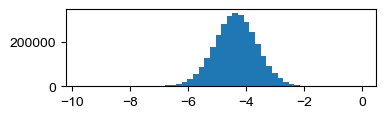

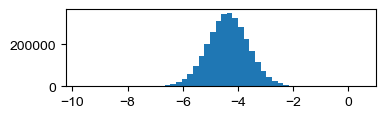

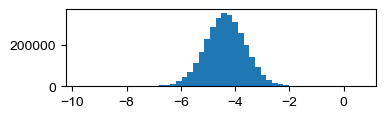

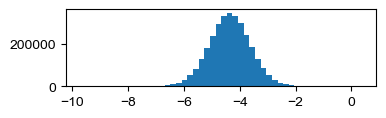

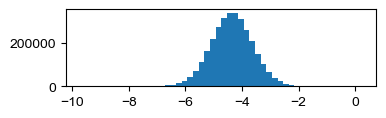

In [73]:
for w in eg_e07_weights:
    plt.figure(figsize=(4,1))
    print(np.linalg.norm(w))
    w = w[w > 6e-5]
    plt.hist(np.log(np.abs(w.ravel())), bins = 50)

In [70]:
eg_e06_weights = get_weights(eg_e06)

Setting split bias
Setting split bias
Setting split bias
Setting split bias
Setting split bias


54.26903
55.147198
54.793884
55.29427
55.74632


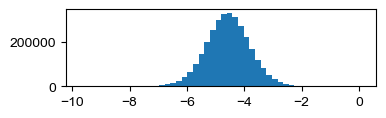

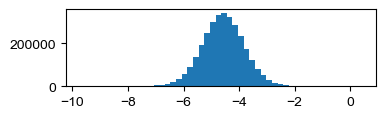

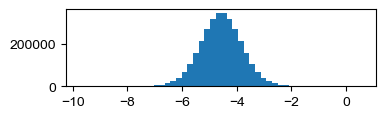

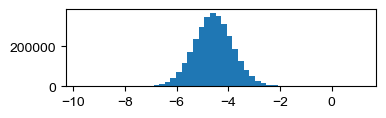

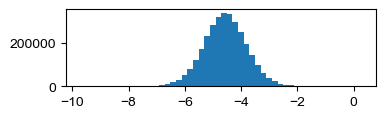

In [74]:
for w in eg_e06_weights:
    plt.figure(figsize=(4,1))
    print(np.linalg.norm(w))
    w = w[w > 6e-5]
    plt.hist(np.log(np.abs(w.ravel())), bins = 50)